In [1]:
# ── Cell 1: Imports ────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from entsoe import EntsoePandasClient
import pandas as pd

In [2]:
# ── Cell 2: Settings ───────────────────────────────────────────────────────
dt    = 15 / 60   # time step: 15 minutes in hours
t_end = 24        # simulate 24 hours
steps = int(t_end / dt)
time  = np.linspace(0, t_end, steps)

# Temperature boundaries
T_MIN = 23.0
T_MAX = 25.0

# Thermal model — sized for worst case (T_OUTDOOR = -10°C)
C     = 10.0   # thermal capacitance
k     = 1.5    # heat loss coefficient
P_MAX = 50.0   # max heating power — sufficient for all scenarios

# MPC settings
HORIZON = 12    # 12 steps = 3 hours ahead

API_KEY = '73049251-6693-4703-bf77-0ffa91d507f8'   # your ENTSO-E key

# Outdoor temperature scenarios to simulate
SCENARIOS = {
    "Mild (+15°C)":     15,
    "Cool (+10°C)":     10,
    "Cold (+5°C)":       5,
    "Very cold (0°C)":   0,
    "Extreme (-10°C)": -10,
}

In [3]:
# ── Cell 3: Helper functions ───────────────────────────────────────────────
def fetch_prices():
    print("Fetching electricity prices from ENTSO-E...")
    client = EntsoePandasClient(api_key=API_KEY)
    today    = pd.Timestamp.now(tz='Europe/Helsinki').normalize()
    tomorrow = today + pd.Timedelta(days=1)
    df = client.query_day_ahead_prices('FI', today, tomorrow).reset_index()
    df.columns = ['timestamp', 'price']
    df['price'] = df['price'] / 1000.0  # €/MWh → €/kWh
    prices = df['price'].values[:96]    # 96 × 15-min = 24h
    # repeat hourly price across 4 × 15-min slots
    prices = np.repeat(prices, 4)[:steps] if len(prices) == 24 else prices[:steps]
    print(f"  Min: {prices.min()*100:.2f}  "
          f"Max: {prices.max()*100:.2f}  "
          f"Avg: {prices.mean()*100:.2f}  c€/kWh")
    return prices

def thermal_model(T, p, T_outdoor):
    dT = (1 / C) * (p * P_MAX - k * (T - T_outdoor))
    return T + dT * dt

# def run_mpc(T_current, price_forecast, T_outdoor):
#     def cost_function(power_sequence):
#         T = T_current
#         total_cost = 0
#         penalty = 0
#         for i, p in enumerate(power_sequence):
#             T = thermal_model(T, p, T_outdoor)
#             total_cost += p * P_MAX * price_forecast[i] * dt
#             if T < T_MIN:
#                 penalty += 100000 * (T_MIN - T) ** 2   # was 1000
#             if T > T_MAX:
#                 penalty += 100000 * (T - T_MAX) ** 2   # was 1000
#         return total_cost + penalty

#     result = minimize(
#         cost_function,
#         np.zeros(HORIZON),
#         method='SLSQP',
#         bounds=[(0, 1)] * HORIZON,
#         options={'maxiter': 100, 'ftol': 1e-6}
#     )
#     return np.clip(result.x[0], 0, 1)

def run_mpc(T_current, price_forecast, T_outdoor):
    """MPC with hard temperature constraints instead of penalty terms."""

    def cost_function(power_sequence):
        T = T_current
        total_cost = 0
        for i, p in enumerate(power_sequence):
            T = thermal_model(T, p, T_outdoor)
            total_cost += p * P_MAX * price_forecast[i] * dt
        return total_cost  # no penalty — constraints handle it

    # build hard constraints: T must stay within [T_MIN, T_MAX] at every step
    constraints = []
    for step in range(HORIZON):
        def make_lower(s):
            def lower(power_sequence):
                T = T_current
                for j in range(s + 1):
                    T = thermal_model(T, power_sequence[j], T_outdoor)
                return T - T_MIN   # must be >= 0
            return lower

        def make_upper(s):
            def upper(power_sequence):
                T = T_current
                for j in range(s + 1):
                    T = thermal_model(T, power_sequence[j], T_outdoor)
                return T_MAX - T   # must be >= 0
            return upper

        constraints.append({'type': 'ineq', 'fun': make_lower(step)})
        constraints.append({'type': 'ineq', 'fun': make_upper(step)})

    # warm start: if temperature is below T_MIN, start with full power
    # otherwise start with zeros — gives the solver a better starting point
    if T_current < T_MIN:
        p0 = np.ones(HORIZON)
    elif T_current > T_MAX:
        p0 = np.zeros(HORIZON)
    else:
        p0 = np.full(HORIZON, 0.3)

    result = minimize(
        cost_function,
        p0,
        method='SLSQP',
        bounds=[(0, 1)] * HORIZON,
        constraints=constraints,
        options={'maxiter': 200, 'ftol': 1e-8}
    )

    # safety fallback: if optimiser failed, use thermostat logic
    if not result.success:
        if T_current < T_MIN:
            return 1.0
        elif T_current > T_MAX:
            return 0.0
        else:
            return 0.3

    return np.clip(result.x[0], 0, 1)

def run_thermostat(prices, T_outdoor):
    T = np.zeros(steps)
    P = np.zeros(steps)
    cost = np.zeros(steps)
    T[0] = T_MIN + (T_MAX - T_MIN) / 2  # start in the middle of range
    for i in range(1, steps):
        p = 1.0 if T[i-1] < T_MIN else (0.0 if T[i-1] > T_MAX else P[i-1])
        P[i] = p
        T[i] = thermal_model(T[i-1], p, T_outdoor)
        cost[i] = cost[i-1] + p * P_MAX * prices[i] * dt
    return T, P, cost

def run_mpc_simulation(prices, T_outdoor):
    T = np.zeros(steps)
    P = np.zeros(steps)
    cost = np.zeros(steps)
    T[0] = T_MIN + (T_MAX - T_MIN) / 2  # start in the middle of range
    for i in range(1, steps):
        forecast_end   = min(i + HORIZON, steps)
        price_forecast = prices[i:forecast_end]
        if len(price_forecast) < HORIZON:
            price_forecast = np.pad(price_forecast,
                                    (0, HORIZON - len(price_forecast)),
                                    mode='edge')
        p    = run_mpc(T[i-1], price_forecast, T_outdoor)
        P[i] = p
        T[i] = thermal_model(T[i-1], p, T_outdoor)
        cost[i] = cost[i-1] + p * P_MAX * prices[i] * dt
    return T, P, cost

In [4]:
prices = fetch_prices()

Fetching electricity prices from ENTSO-E...
  Min: 0.89  Max: 10.04  Avg: 5.03  c€/kWh


In [5]:
# ── Cell 5: Run all scenarios ──────────────────────────────────────────────
results = {}

for name, T_out in SCENARIOS.items():
    print(f"\nRunning scenario: {name}")
    T_base, P_base, cost_base = run_thermostat(prices, T_out)
    T_mpc,  P_mpc,  cost_mpc  = run_mpc_simulation(prices, T_out)
    results[name] = {
        "T_out":     T_out,
        "T_base":    T_base,   "P_base":  P_base,  "cost_base":  cost_base,
        "T_mpc":     T_mpc,    "P_mpc":   P_mpc,   "cost_mpc":   cost_mpc,
        "savings":   cost_base[-1] - cost_mpc[-1],
        "savings_pct": (cost_base[-1] - cost_mpc[-1]) / cost_base[-1] * 100
                      if cost_base[-1] > 0 else 0,
        "mpc_in_range":  np.mean((T_mpc  >= T_MIN) & (T_mpc  <= T_MAX)) * 100,
        "base_in_range": np.mean((T_base >= T_MIN) & (T_base <= T_MAX)) * 100,
    }
    print(f"  Thermostat cost: €{cost_base[-1]:.4f} | "
          f"MPC cost: €{cost_mpc[-1]:.4f} | "
          f"Savings: {results[name]['savings_pct']:.1f}%")

print("\nAll scenarios complete!")


Running scenario: Mild (+15°C)
  Thermostat cost: €16.6019 | MPC cost: €11.5733 | Savings: 30.3%

Running scenario: Cool (+10°C)
  Thermostat cost: €24.2770 | MPC cost: €19.9601 | Savings: 17.8%

Running scenario: Cold (+5°C)
  Thermostat cost: €34.6184 | MPC cost: €28.6461 | Savings: 17.3%

Running scenario: Very cold (0°C)
  Thermostat cost: €42.3576 | MPC cost: €37.6764 | Savings: 11.1%

Running scenario: Extreme (-10°C)
  Thermostat cost: €58.2399 | MPC cost: €57.7343 | Savings: 0.9%

All scenarios complete!


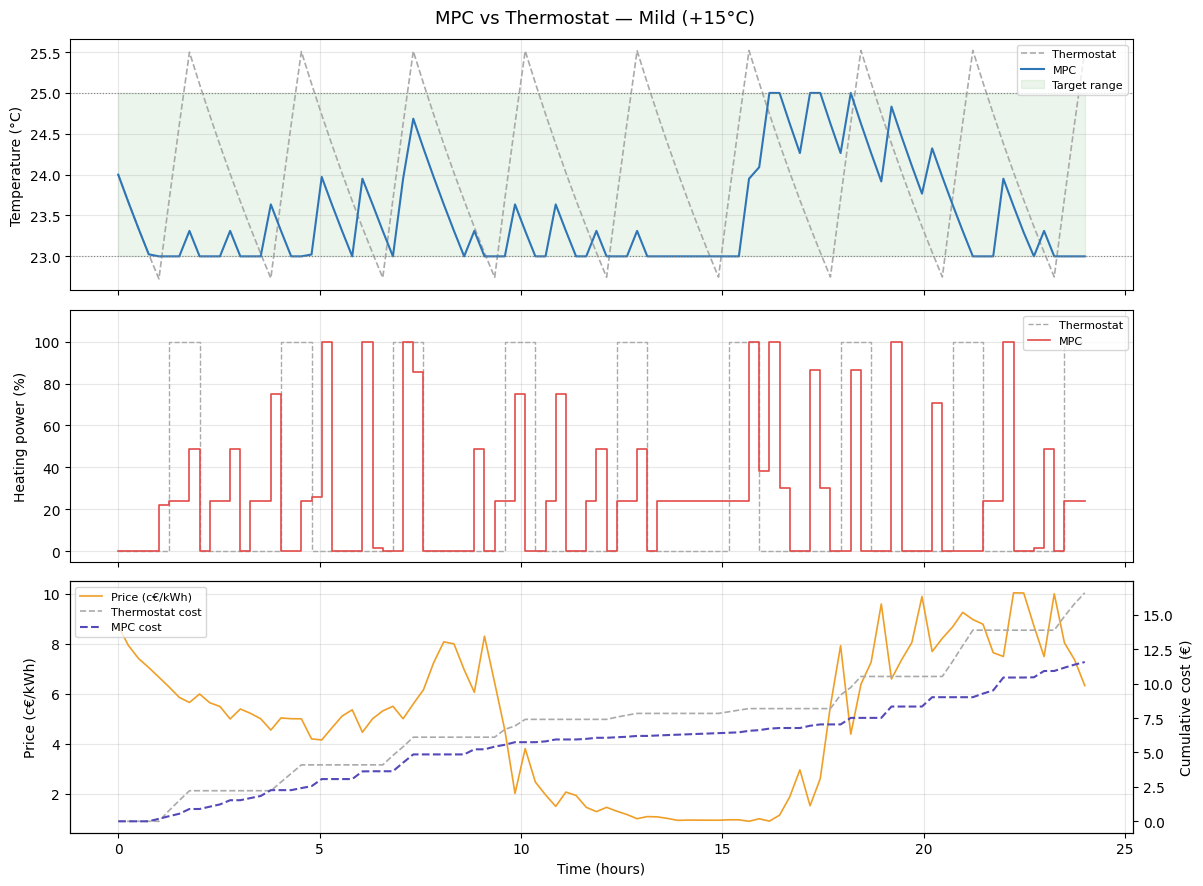

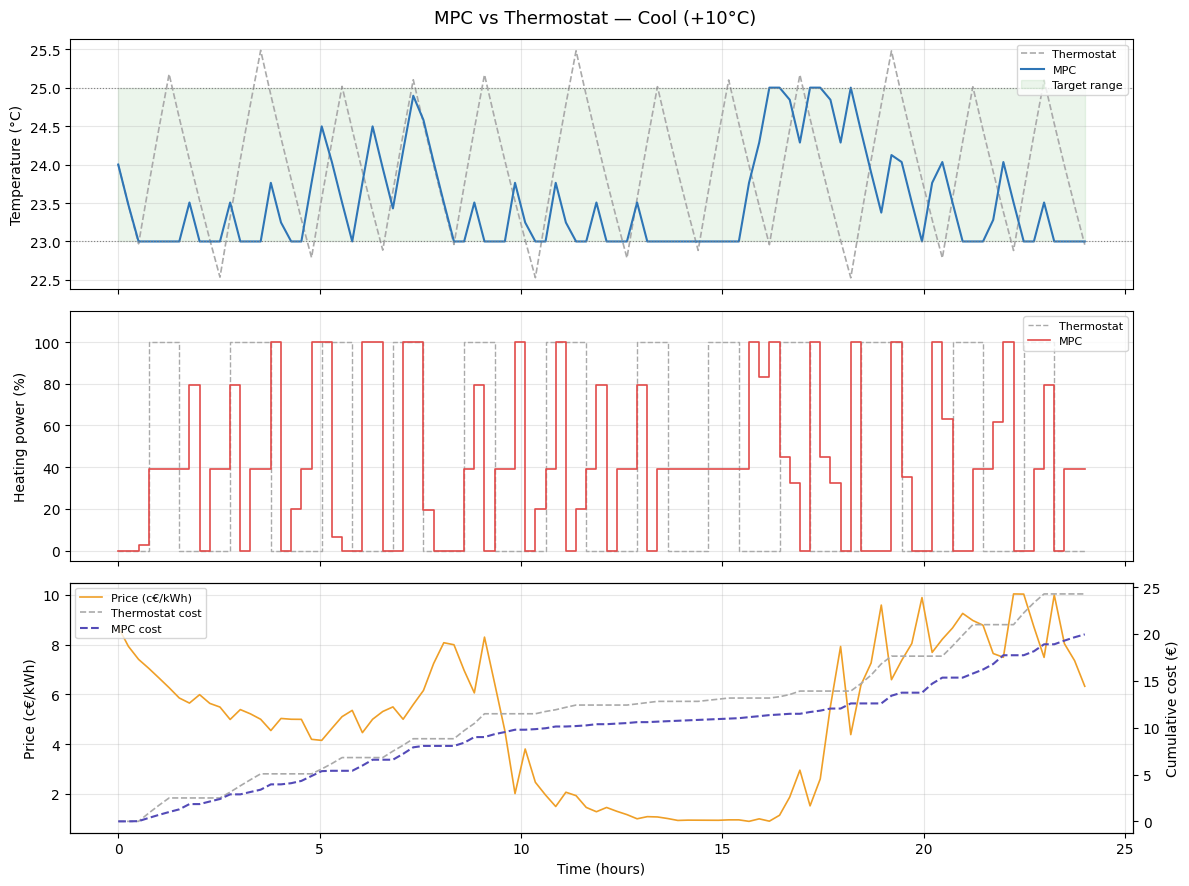

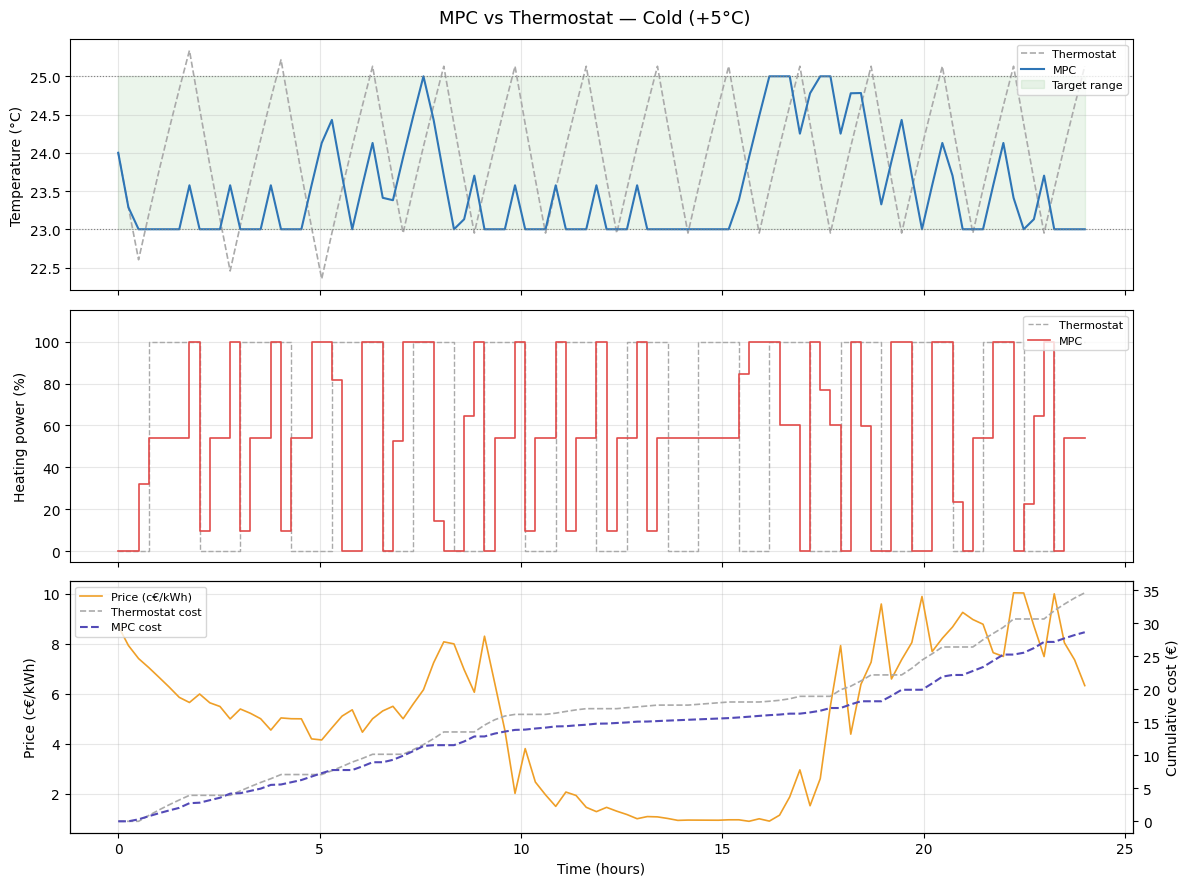

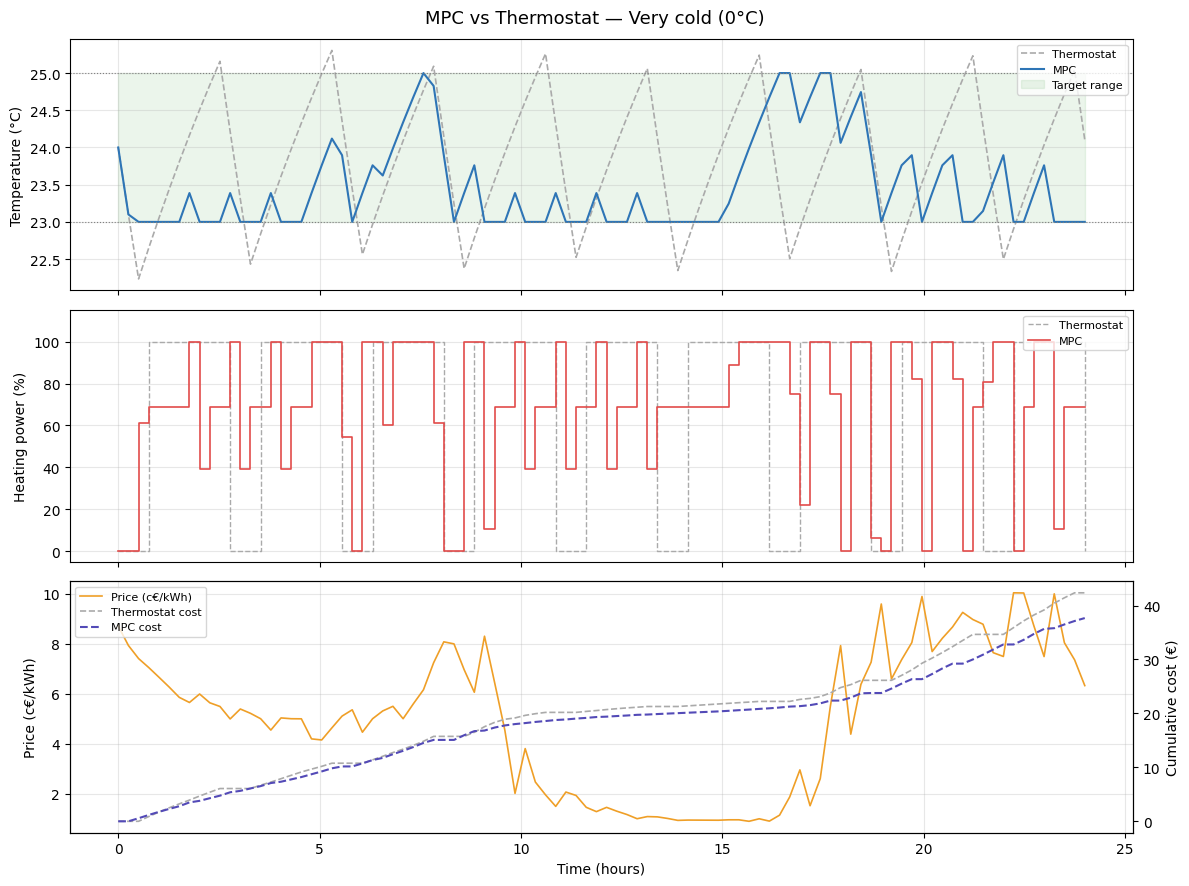

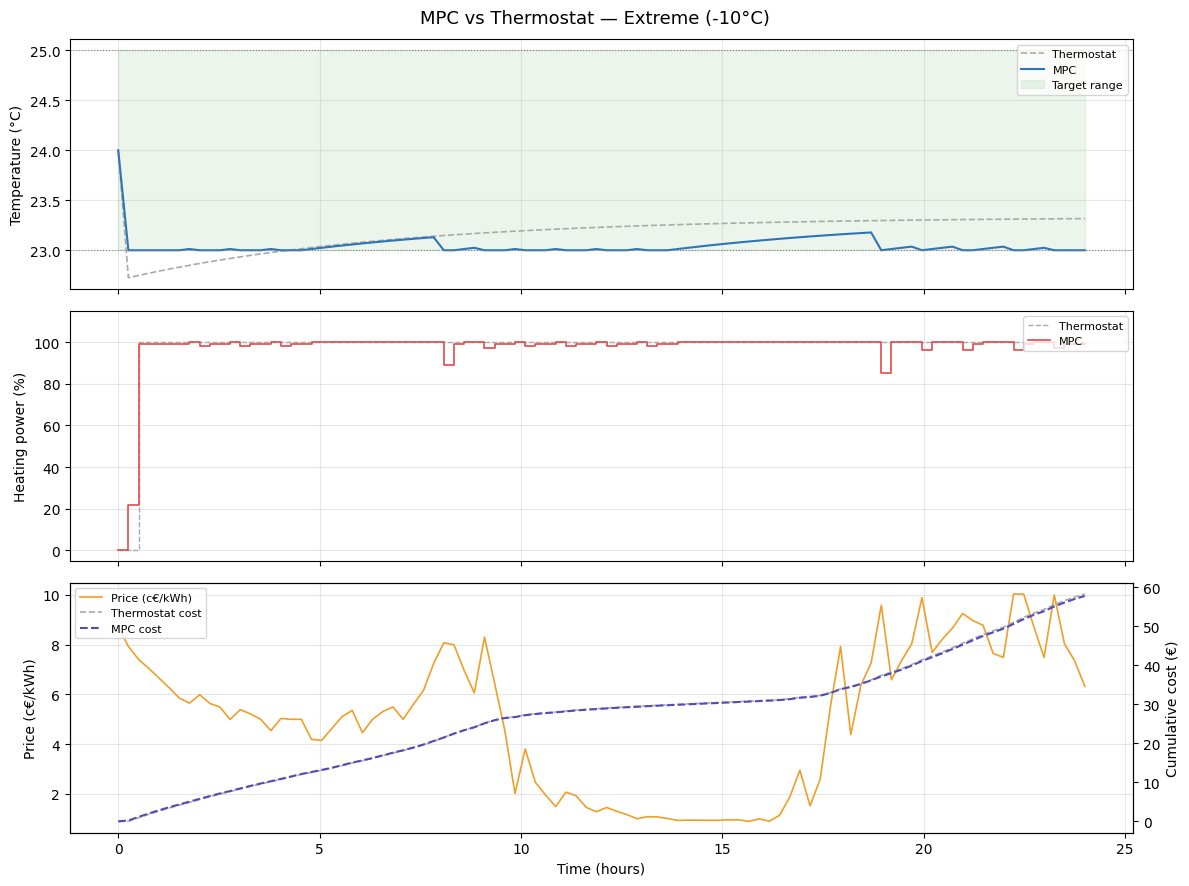

In [6]:
# ── Cell 6: Plot — one figure per scenario ─────────────────────────────────
for name, r in results.items():
    fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
    fig.suptitle(f"MPC vs Thermostat — {name}", fontsize=13)

    # Temperature
    axes[0].plot(time, r['T_base'], color="#AAAAAA", linewidth=1.2,
                 linestyle="--", label="Thermostat")
    axes[0].plot(time, r['T_mpc'],  color="#2E75B6", linewidth=1.5,
                 label="MPC")
    axes[0].axhline(T_MIN, color="gray", linestyle=":", linewidth=0.8)
    axes[0].axhline(T_MAX, color="gray", linestyle=":", linewidth=0.8)
    axes[0].fill_between(time, T_MIN, T_MAX, alpha=0.08,
                         color="green", label="Target range")
    axes[0].set_ylabel("Temperature (°C)")
    axes[0].legend(loc="upper right", fontsize=8)
    axes[0].grid(True, alpha=0.3)

    # Heating power
    axes[1].step(time, r['P_base'] * 100, color="#AAAAAA", linewidth=1.0,
                 linestyle="--", where="post", label="Thermostat")
    axes[1].step(time, r['P_mpc']  * 100, color="#E24B4A", linewidth=1.2,
                 where="post", label="MPC")
    axes[1].set_ylabel("Heating power (%)")
    axes[1].set_ylim(-5, 115)
    axes[1].legend(loc="upper right", fontsize=8)
    axes[1].grid(True, alpha=0.3)

    # Price + cumulative cost
    ax2b = axes[2].twinx()
    axes[2].plot(time, prices * 100, color="#EF9F27",
                 linewidth=1.2, label="Price (c€/kWh)")
    ax2b.plot(time, r['cost_base'], color="#AAAAAA", linewidth=1.2,
              linestyle="--", label="Thermostat cost")
    ax2b.plot(time, r['cost_mpc'],  color="#534AB7", linewidth=1.5,
              linestyle="--", label="MPC cost")
    axes[2].set_ylabel("Price (c€/kWh)")
    ax2b.set_ylabel("Cumulative cost (€)")
    axes[2].set_xlabel("Time (hours)")
    axes[2].grid(True, alpha=0.3)
    lines1, labels1 = axes[2].get_legend_handles_labels()
    lines2, labels2 = ax2b.get_legend_handles_labels()
    axes[2].legend(lines1 + lines2, labels1 + labels2,
                   loc="upper left", fontsize=8)

    plt.tight_layout()
    plt.savefig(f"scenario_{name.split()[0]}.png", dpi=150)
    plt.show()


Scenario                T_out   Base €    MPC €  Savings €  Savings %  MPC in range  Base in range
----------------------------------------------------------------------------------------------------
Mild (+15°C)              15°C €16.6019 €11.5733 €   5.0285      30.3%         84.4%          72.9%
Cool (+10°C)              10°C €24.2770 €19.9601 €   4.3169      17.8%         90.6%          74.0%
Cold (+5°C)                5°C €34.6184 €28.6461 €   5.9723      17.3%         87.5%          71.9%
Very cold (0°C)            0°C €42.3576 €37.6764 €   4.6812      11.1%         83.3%          71.9%
Extreme (-10°C)          -10°C €58.2399 €57.7343 €   0.5056       0.9%         85.4%          83.3%

Scenario                MPC violations  Base violations
--------------------------------------------------------
Mild (+15°C)                       15 steps              26 steps
Cool (+10°C)                        9 steps              25 steps
Cold (+5°C)                        12 steps          

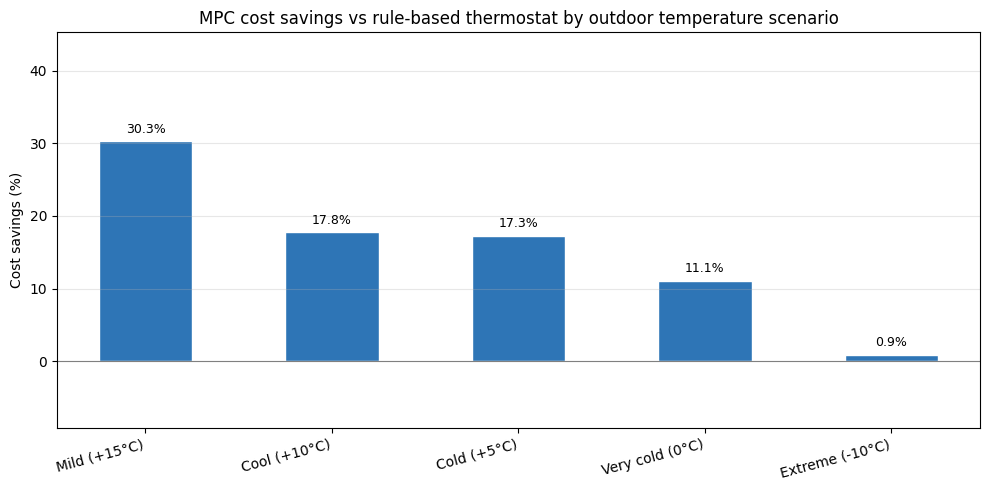

In [7]:
# ── Cell 7: Summary comparison across all scenarios ────────────────────────
print(f"\n{'Scenario':<22} {'T_out':>6} {'Base €':>8} {'MPC €':>8} "
      f"{'Savings €':>10} {'Savings %':>10} "
      f"{'MPC in range':>13} {'Base in range':>14}")
print("-" * 100)

for name, r in results.items():
    print(f"{name:<22} {r['T_out']:>5}°C "
          f"€{r['cost_base'][-1]:>7.4f} "
          f"€{r['cost_mpc'][-1]:>7.4f} "
          f"€{r['savings']:>9.4f} "
          f"{r['savings_pct']:>9.1f}% "
          f"{r['mpc_in_range']:>12.1f}% "
          f"{r['base_in_range']:>13.1f}%")
    
# ── Check constraint violations ────────────────────────────────────────────
print(f"\n{'Scenario':<22} {'MPC violations':>15} {'Base violations':>16}")
print("-" * 56)

for name, r in results.items():
    mpc_violations  = np.sum(r['T_mpc']  < T_MIN) + np.sum(r['T_mpc']  > T_MAX)
    base_violations = np.sum(r['T_base'] < T_MIN) + np.sum(r['T_base'] > T_MAX)
    print(f"{name:<22} {mpc_violations:>14} steps  {base_violations:>14} steps")

# ── Bar chart: savings by scenario ────────────────────────────────────────
names    = list(results.keys())
savings  = [r['savings_pct'] for r in results.values()]
colors   = ["#2E75B6" if s > 0 else "#E24B4A" for s in savings]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(names, savings, color=colors, width=0.5, edgecolor="white")
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_ylabel("Cost savings (%)")
ax.set_title("MPC cost savings vs rule-based thermostat by outdoor temperature scenario")
ax.bar_label(bars, fmt="%.1f%%", padding=4, fontsize=9)
ax.set_ylim(min(savings) - 10, max(savings) + 15)
ax.grid(True, axis='y', alpha=0.3)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig("savings_by_scenario.png", dpi=150)
plt.show()